In [1]:

import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy
import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats
import importlib
import multi_exp_log
sys.path.append('..')
import plot_settings

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(multi_exp_log)

import_reload()
import warnings
warnings.filterwarnings("ignore", message=".*__array_wrap__.*")

# Importing data

In [2]:
DT = 1
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [ ]:


def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        sep=';',
        comment="%"
    )
    # cols = u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
    #df.columns = ['u_par','C','t','V','I','F','u','Ue','eta','trajectory','dV','dF','soc']
    # Sort by time within each batch
    return df


path = f'7_merged_data'

data = read_data(path)
display(data.head())


,u_par,C,t,V,I,F,u,Ue,eta,trajectory
0,0.4,2.2,0.0,4.239833,10.952074,0.030566,-0.057493,4.324996,-0.085164,0
1,0.4,2.2,1.0,4.211952,10.952074,0.030096,-0.057493,4.323139,-0.111187,0
2,0.4,2.2,2.0,4.195213,10.952074,0.029624,-0.057493,4.321278,-0.126065,0
3,0.4,2.2,3.0,4.183479,10.952074,0.029153,-0.057493,4.319417,-0.135938,0
4,0.4,2.2,4.0,4.176773,10.952074,0.028682,-0.057493,4.317557,-0.140783,0


To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

## The sampled terrain

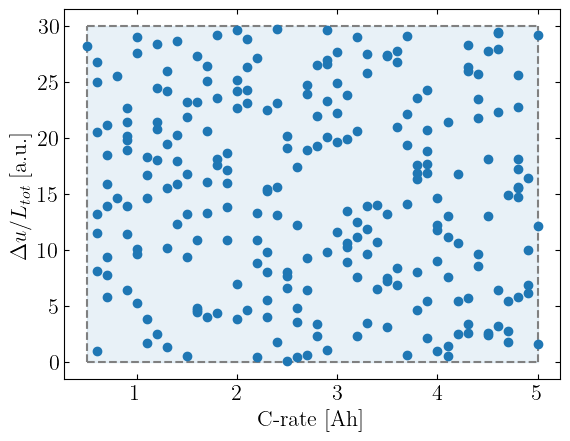

In [4]:
u_C_pairs = data.loc[data['t'] == 0, ['u_par', 'C']]
plt.xlabel('C-rate [Ah]')
plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
plt.vlines(0.5,0,30, color='gray', linestyle='--')
plt.vlines(5,0,30, color='gray', linestyle='--')
plt.hlines(0,0.5,5, color='gray', linestyle='--')
plt.hlines(30,0.5,5, color='gray', linestyle='--')
plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
plt.plot(u_C_pairs['C'], u_C_pairs['u_par'], 'o')

# Plotting data

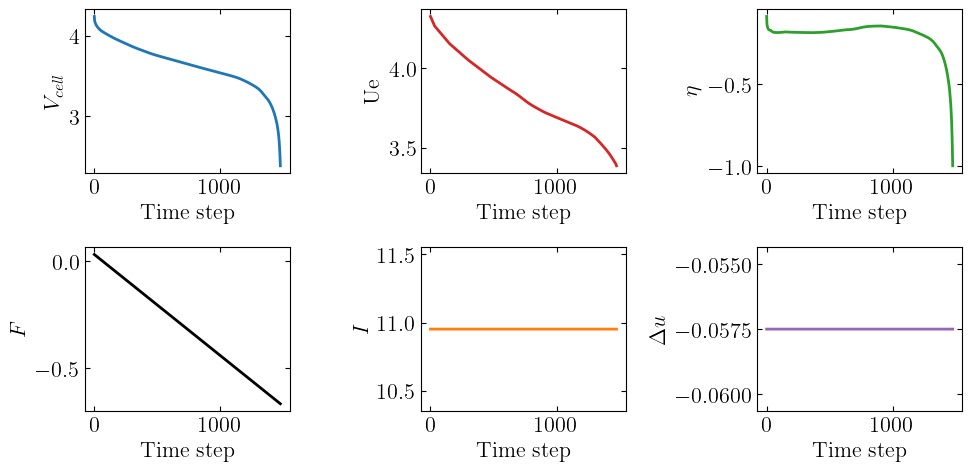

In [5]:

plot_idx = data['trajectory'] == 0
f, ax = plt.subplots(2, 3, figsize=(10, 5))
ax[0,0].plot(data['V'][plot_idx], '-', color = colors[0], lw = 2)
ax[0,0].set_xlabel('Time step')
ax[0,0].set_ylabel('$V_{cell}$')
ax[0,1].plot(data['Ue'][plot_idx], '-', color = colors[1], lw = 2)
ax[0,1].set_xlabel('Time step')
ax[0,1].set_ylabel('Ue')
ax[0,2].plot(data['eta'][plot_idx], '-', color = colors[2], lw = 2)
ax[0,2].set_xlabel('Time step')
ax[0,2].set_ylabel(r'$\eta$')
ax[1,0].plot(data['F'][plot_idx], lw = 2,color = colors[3])
ax[1,0].set_xlabel('Time step')
ax[1,0].set_ylabel(r'$F$')
ax[1,1].plot(data['I'][plot_idx], lw = 2,color = colors[4])
ax[1,1].set_xlabel('Time step')
ax[1,1].set_ylabel(r'$I$')
ax[1,2].plot(data['u'][plot_idx], lw = 2,color = colors[5])
ax[1,2].set_xlabel('Time step')
ax[1,2].set_ylabel(r'$\Delta u$')

plt.tight_layout()
plt.show()

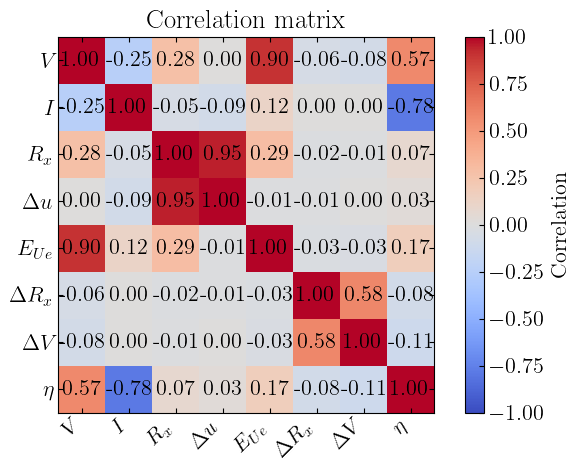

In [6]:
# Correlation matrix for current signals in this batch

X = data[['V','I','F','u_par','Ue','dF','dV','eta']].values
feature_names = ['$V$','$I$','$R_x$',r'$\Delta u$','$E_{Ue}$',r'$\Delta R_x$',r'$\Delta V$',r'$\eta$']
with np.errstate(invalid="ignore", divide="ignore"):
    corr = np.corrcoef(X, rowvar=False)


fig, ax_corr = plt.subplots(figsize=(7, 5))
im = ax_corr.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax_corr.set_xticks(np.arange(len(feature_names)))
ax_corr.set_yticks(np.arange(len(feature_names)))
ax_corr.set_xticklabels(feature_names, rotation=45, ha="right")
ax_corr.set_yticklabels(feature_names)
ax_corr.set_title("Correlation matrix")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax_corr.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax_corr, label="Correlation")
plt.tight_layout()
plt.show()

53.164 GN/mm


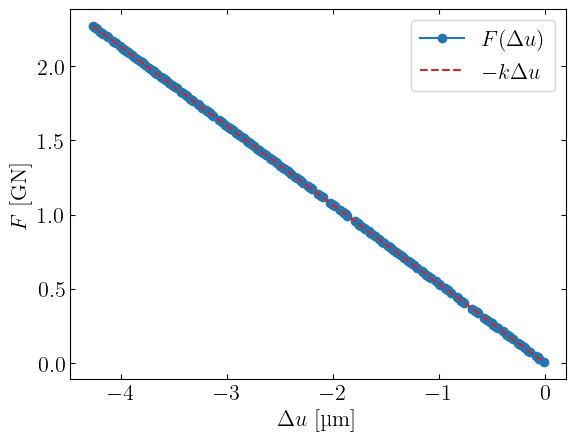

In [7]:
traj = 0
#plt.plot(data['u'][data['trajectory'] == traj], data['F'][data['trajectory'] == traj], lw = 2, color = colors[0])
groups = data.groupby('u')['F']


first_F = data.groupby('u')['F'].first()
k = abs(first_F / (data.groupby('u')['u'].first()))
plt.plot(data.groupby('u')['u'].first(), first_F, 'o-', color = colors[0], label = r'$F(\Delta u)$')
plt.plot(data.groupby('u')['u'].first(), -k * data.groupby('u')['u'].first(), '--', color = colors[1], label = r'$-k\Delta u$')
plt.xlabel(r'$\Delta u$ [µm]')
plt.ylabel(r'$F$ [GN]')
plt.legend()
print(f'{100 * k.values[0]:.3f} GN/mm')


Text(0, 0.5, '$F$ [MN]')

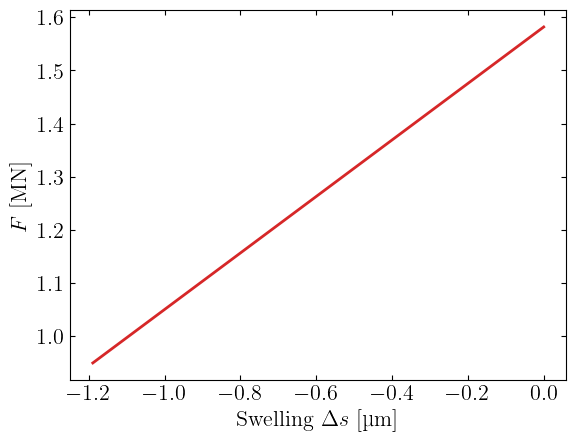

In [8]:
traj = 1

ds = data['F'][data['trajectory'] == traj] / k.values[0] + data['u'][data['trajectory'] == traj] 

plt.plot(ds,data['F'][data['trajectory'] == traj], lw = 2, color = colors[1])
plt.xlabel(r'Swelling $\Delta s$ [µm]')
plt.ylabel(r'$F$ [MN]')

In [9]:
def GP_process(traj_max = False):
    sig = 1
    l = 0.1
    alpha = [l, sig]
    traj_max = data['trajectory'][np.argmin(data['soc'].values)]
    x_gp = data['soc'][data['trajectory'] == traj_max].values
    y_gp = data['Ue'][data['trajectory'] == traj_max].values
    kernel_GP = gp.kernels.RBF(length_scale=alpha[0]) * gp.kernels.ConstantKernel(constant_value=alpha[1])
    gp_model = gp.GaussianProcessRegressor(kernel=kernel_GP,optimizer=None,normalize_y=False)

    gp_model.fit(x_gp.reshape(-1,1), y_gp.reshape(-1,1))
    if traj_max:
        return gp_model, traj_max
    else:
        return gp_model
gp_fit,tr_max = GP_process(traj_max = True)

# print tr_max and the minimum soc value
print(f"Trajectory with minimum SOC: {tr_max}")
print(f"Minimum SOC value: {np.min(data['soc'].values):.4f}")

def soc_to_Ue(soc, gp_fit = gp_fit, return_torch = False):
    if return_torch:
        return torch.from_numpy(gp_fit.predict(np.asarray(soc).reshape(-1,1))).float()
    else:
        return gp_fit.predict(soc.reshape(-1,1))

Trajectory with minimum SOC: 136
Minimum SOC value: 0.0210


GP sampling took 0.8066 seconds for 7049 points => 0.114 ms/point
MSE: 5.271350e-07


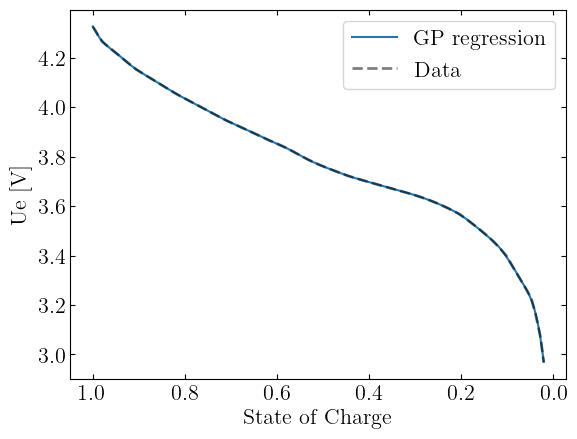

In [10]:
start = time.perf_counter()
Ue_sample = soc_to_Ue(data['soc'][data['trajectory'] == tr_max].values)
end = time.perf_counter()
print(f"GP sampling took {end - start:.4f} seconds for {len(data['soc'][data['trajectory'] == tr_max].values)} points => {len(data['soc'][data['trajectory'] == tr_max].values)**(-1) *1000* (end - start):.3f} ms/point")
plt.plot((data['soc'][data['trajectory'] == tr_max].values), Ue_sample, color = colors[0], label = 'GP regression')
plt.plot(data['soc'][data['trajectory'] == tr_max].values, data['Ue'][data['trajectory'] == tr_max].values, lw = 2, color = 'black', label = 'Data',ls = '--', alpha = 0.5)
plt.xlabel('State of Charge')
plt.gca().invert_xaxis()
plt.ylabel('Ue [V]')
plt.legend()
print(f'MSE: {np.mean((Ue_sample - data["Ue"][data["trajectory"] == tr_max].values)**2):.6e}')

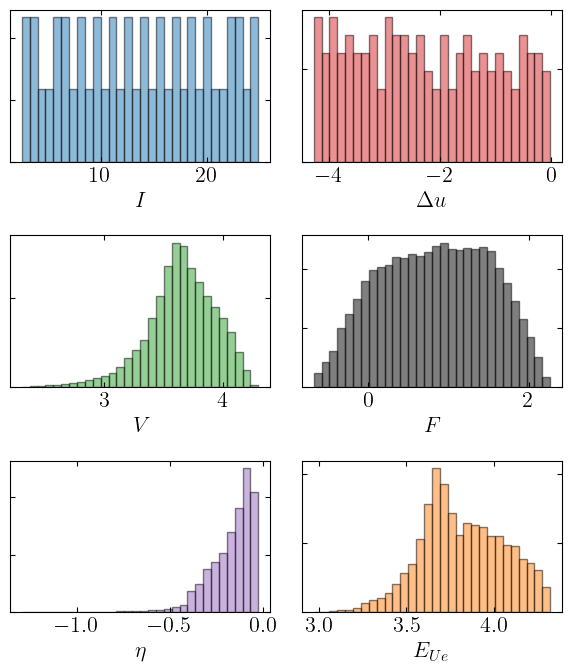

In [11]:
f, ax = plt.subplots(3,2,figsize=(6, 7))
ax[0,0].hist(np.unique(data['I']), bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[0,1].hist(np.unique(data['u']) , bins=30, color=colors[1], alpha=0.5,edgecolor='black',density=True)
ax[1,0].hist(data['V'], bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[1,1].hist(np.unique(data['F']), bins=30, color=colors[3], alpha=0.5,edgecolor='black',density=True)
ax[2,1].hist(data['Ue'], bins=30, color=colors[4], alpha=0.5,edgecolor='black',density=True)
ax[2,0].hist((data['eta']), bins=30, color=colors[5], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('$I$')
ax[0,1].set_xlabel(r'$\Delta u$')
ax[1,0].set_xlabel('$V$')
ax[1,1].set_xlabel('$F$')
ax[2,1].set_xlabel('$E_{Ue}$')
ax[2,0].set_xlabel(r'$\eta$')
#ax[2,0].set_xlabel('$E_{Ue}$')
#ax[2,1].set_xlabel('$d$')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()

In [96]:
N_trajs = len(data['trajectory'].unique())


X = data[['I','u','soc','Ue','trajectory']].values
y = data[['V','F','trajectory']].values

In [97]:
x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

split = (data['trajectory']<=int(N_trajs *0.8)).sum()

def _split_flat(arr, split = split):
    return arr[:split], arr[split:]   # Same as reshape(B * T, C)    # (B*T, 4)

x_train, x_test = _split_flat(x_tensor); y_train, y_test = _split_flat(y_tensor)

print(f'Number of trajectories in train: {int(N_trajs * 0.8)} out of {N_trajs}')

print(f'X shape {x_tensor.shape}\ty shape {y_tensor.shape}\nX-train shape: {x_train.shape}\ty-train shape: {y_train.shape}\nX-test shape: {x_test.shape}\ty-test shape: {y_test.shape}')


#df_train = data[data['trajectory'] <= int(N_trajs * 0.8)]
#df_test = data[data['trajectory'] > int(N_trajs * 0.8)]

#train_loader_flat = DataLoader(TensorDataset(x_eval, y_train), shuffle=False)

Number of trajectories in train: 198 out of 248
X shape torch.Size([415557, 5])	y shape torch.Size([415557, 3])
X-train shape: torch.Size([334590, 5])	y-train shape: torch.Size([334590, 3])
X-test shape: torch.Size([80967, 5])	y-test shape: torch.Size([80967, 3])


In [14]:
''' Mk 1 '''
import torch.nn.functional as TF

def ECM_box(Ue, I, R0, U1):
    #Ue = soc_to_Ue(soc,return_torch=True    )
    return Ue - I * R0 - U1

def Mech_box(u,Fs , k = k.values[0]):
    return -k * u + Fs

def soc_force_func(soc, variable = 'F'):
    
    if variable == 'F': 
        forcing_const = 0.995
    elif variable == 'U':
        forcing_const = 0.995
    return 1 - np.exp(-(1-soc) / (1 - forcing_const));

def R0_func(I,u):
    x0 = u
    x1 = I
    return x0*(-0.0001887521) - 7.049519e-5*x1 + 0.00844669;



class Net(nn.Module):
    def __init__(self, input_size=3, hidden_size=256): 
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)   # output size is 2 for (V_cell, F)
        )

    def forward(self, x):
        
        if True:
            Fs_raw = self.net(x)[:,0] #* force_func(soc)  # (T,)
            U1_raw = self.net(x)[:,1] 
            soc = x[:,2]
            Fs = soc_force_func(soc, variable='F') * Fs_raw;
            U1 = soc_force_func(soc, variable = 'U') * TF.softplus(U1_raw);
            
            return Fs, U1
        else:
            R0_raw, Fs_raw, U1_raw = self.net(x)[:,0], self.net(x)[:,1], self.net(x)[:,2]
            R0 = R0_raw#torch.clamp(R0_raw, 0, 1) #TF.softplus(R0_raw)  # Ensure R0 is non-negative
            Fs = Fs_raw#force_func(soc) * Fs_raw
            U1 = U1_raw # torch.clamp(U1_raw, 0, 1) #TF.softplus(U1_raw)  # Ensure U1 is non-negative

            return R0, Fs, U1

model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)  

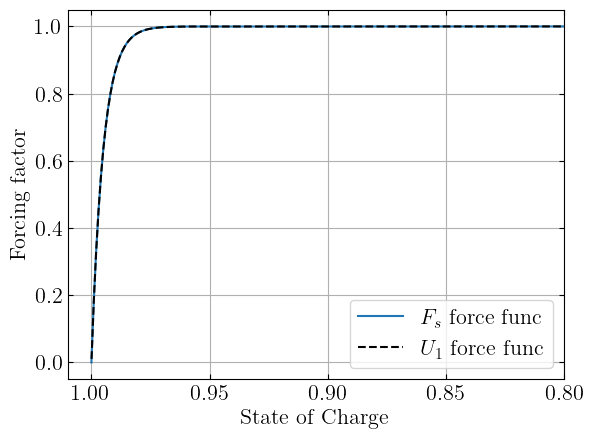

In [15]:
plt.plot(np.linspace(0,1,1000), soc_force_func(np.linspace(0,1,1000), variable='F'), label = r'$F_s$ force func',color = colors[0])
plt.plot(np.linspace(0,1,1000), soc_force_func(np.linspace(0,1,1000), variable = 'U'), label = r'$U_1$ force func',color = colors[3],ls = '--')
plt.xlim(0.8,1.01)
plt.xlabel('State of Charge')
plt.ylabel('Forcing factor')
plt.legend()
plt.grid()
plt.gca().invert_xaxis()

In [ ]:
try: 
    print(summary(model, input_data=x_eval[:2]))
except Exception as e:
    print(f"Error in model summary: {e}")

Error in model summary: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: []


In [ ]:
def training(epochs=30, model=model, optimizer=optimizer, x_eval=x_eval, y_train=y_train, N_trajs=N_trajs):
    history = {"loss": [], "V_loss": [], "F_loss": [], "time per ep": []}

    model.train()
    tot_time = 0.
    MAX_TIME_min = 3.
    for ep in range(epochs):
        start_t = time.perf_counter()    
        ep_loss = 0.0

        for traj in range(int(N_trajs * 0.8)):

            x_traj = x_train[x_train[:, -1] == traj]
            y_traj = y_train[y_train[:, -1] == traj]

            # Inputs
            model_input = x_traj[:, :-1]      # (T, 3)
            model_target = y_traj[:,:-1]     # (T, 2)

            I   = model_input[:, 0]
            u   = model_input[:, 1]
            soc = model_input[:, 2]
            Ue  = model_input[:, 3]
            R0  = R0_func(I,u)
            
            #Ue = soc_to_Ue(soc, return_torch=True)  # (T,)      

            # Forward
            Fs, U1 = model(model_input[:,:3])     # (T,), (T,)

            y_pred = torch.stack([
                ECM_box(Ue, I, R0, U1),
                Mech_box(u, Fs)
            ], dim=1)                       # (T, 2)

            V_loss = nn.MSELoss()(y_pred[:,0], model_target[:,0])
            F_loss = nn.MSELoss()(y_pred[:,1], model_target[:,1])
            U_1_curve_loss = ((U1[2:] - 2*U1[1:-1] + U1[:-2])**2).mean()
            loss = V_loss + F_loss + 1e-2 * U_1_curve_loss

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            ep_loss += loss.item()

        ep_loss /= N_trajs

        history["loss"].append(ep_loss)
        history["V_loss"].append(V_loss.item() / N_trajs)
        history["F_loss"].append(F_loss.item() / N_trajs)
        end_t = time.perf_counter()
        history["time per ep"].append(end_t - start_t)   
        
        tot_time += end_t - start_t
       
        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')

        if tot_time > MAX_TIME_min*60:
            print(f"Early stopping: Total training time exceeded {MAX_TIME_min} minutes.")
            break
        print(f"Epoch {ep+1} | loss {ep_loss:.2e} | V_loss {V_loss.item():.2e} | F_loss {F_loss.item():.2e} | time {end_t - start_t:.2f}s")

    return history  

In [39]:
history = training(epochs=500)

ETA: 23.28 min
Epoch 1 | loss 1.86e-03 | V_loss 1.07e-03 | F_loss 9.43e-06 | time 2.79s
Epoch 2 | loss 1.54e-03 | V_loss 3.52e-03 | F_loss 1.07e-04 | time 1.95s
Epoch 3 | loss 1.31e-03 | V_loss 3.18e-03 | F_loss 1.45e-05 | time 1.81s
Epoch 4 | loss 1.25e-03 | V_loss 1.40e-03 | F_loss 6.92e-04 | time 1.73s
Epoch 5 | loss 6.98e-04 | V_loss 1.23e-03 | F_loss 1.12e-04 | time 2.64s
Epoch 6 | loss 1.02e-03 | V_loss 3.79e-03 | F_loss 4.13e-05 | time 1.82s
Epoch 7 | loss 7.96e-04 | V_loss 3.06e-03 | F_loss 2.13e-05 | time 1.63s
Epoch 8 | loss 6.45e-04 | V_loss 1.25e-03 | F_loss 5.90e-05 | time 1.50s
Epoch 9 | loss 2.92e-03 | V_loss 2.51e-03 | F_loss 1.55e-03 | time 1.58s
Epoch 10 | loss 2.46e-03 | V_loss 1.80e-03 | F_loss 2.07e-04 | time 1.79s
Epoch 11 | loss 1.19e-03 | V_loss 3.18e-03 | F_loss 7.03e-04 | time 1.55s
Epoch 12 | loss 8.55e-04 | V_loss 1.88e-03 | F_loss 1.20e-04 | time 1.60s
Epoch 13 | loss 1.46e-03 | V_loss 1.34e-03 | F_loss 1.84e-05 | time 1.64s
Epoch 14 | loss 7.01e-04 | V_los

0.00034940365192362096


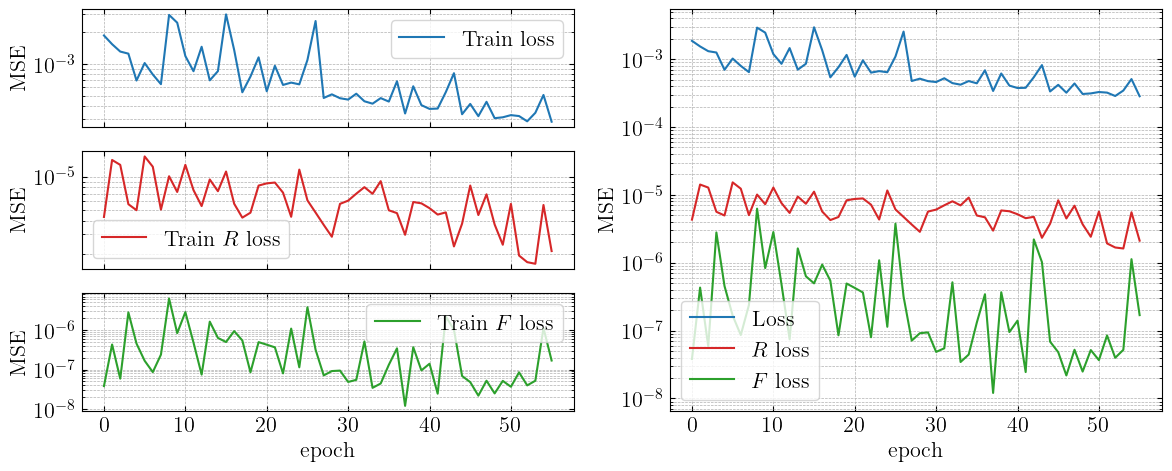

In [40]:
print(np.mean(history['loss'][-5:]))

fig, ax = plt.subplot_mosaic(
    [
        ["loss", "combined"],
        ["V_loss", "combined"],
        ["F_loss", "combined"]
    ],
    figsize=(12, 5),
    sharex=True
)

# Individual plots
ax["loss"].semilogy(history["loss"], label="Train loss", color=colors[0])
ax["V_loss"].semilogy(history["V_loss"], label=r"Train $R$ loss", color=colors[1])
ax["F_loss"].semilogy(history["F_loss"], label=r"Train $F$ loss", color=colors[2])

# Combined plot (all together)
ax["combined"].semilogy(history["loss"], label="Loss", color=colors[0])
ax["combined"].semilogy(history["V_loss"], label=r"$R$ loss", color=colors[1])
ax["combined"].semilogy(history["F_loss"], label=r"$F$ loss", color=colors[2])

# Labels and styling
ax["F_loss"].set_xlabel("epoch")
ax["combined"].set_xlabel("epoch")

for key in ["loss", "V_loss", "F_loss", "combined"]:
    ax[key].set_ylabel("MSE")
    ax[key].legend()
    ax[key].grid(True, which="both", ls="--", lw=0.5)

plt.tight_layout()
plt.show()

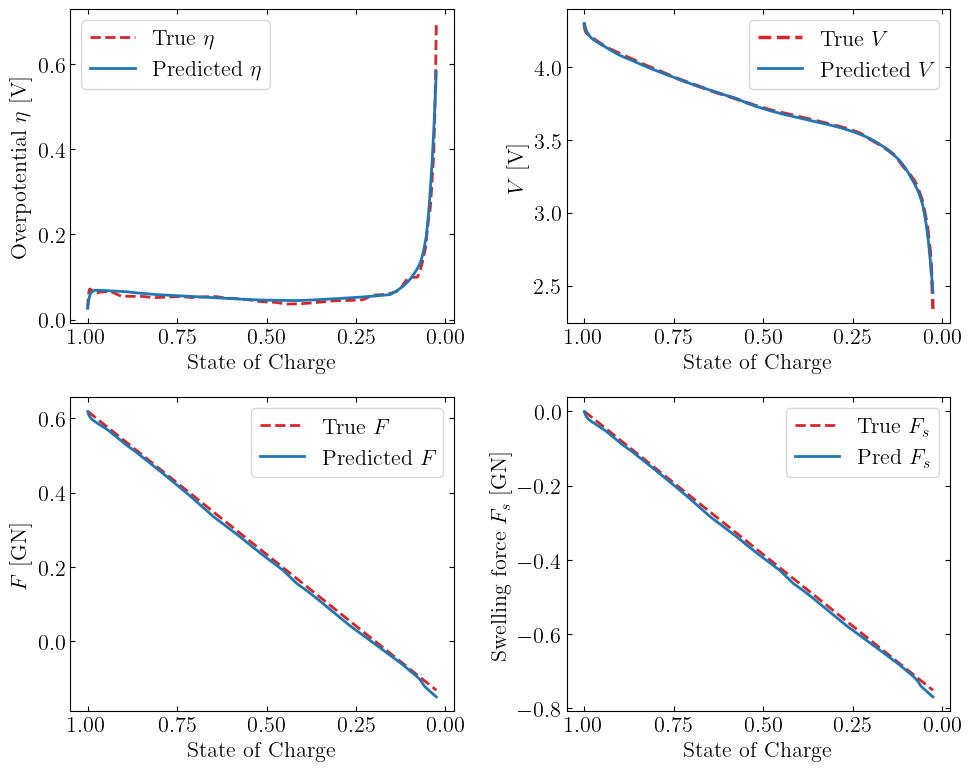

In [113]:
def evaluate(model, x_test, y_test):
    model.eval()
    with torch.no_grad():
        I = x_test[:,0]
        u = x_test[:,1]
        soc = x_test[:,2]
        #Ue = x_test[:,3]
        Ue = soc_to_Ue(soc, return_torch=True)  # (T,)
        R0 = R0_func(I,u)
        F_pred, U1_pred = model(x_test[:,:3])
        y_pred = torch.stack([ECM_box(Ue,I,R0, U1_pred), Mech_box(u,F_pred)],dim=1)

        #test_loss = nn.MSELoss()(y_pred, y_test).item()
    #print(f"Test MSE: {test_loss:.3e}")
    return y_pred.detach().numpy(), R0, F_pred.detach().numpy(), U1_pred.detach().numpy()  





def plot_predictions(traj_eval, test = False, x = x_tensor, y = y_tensor,model  = model, k = k):
    if test:
        traj_eval += int(N_trajs * 0.8)
        
    y_pred, R0, F, U1 = evaluate(model, x[x[:,-1] == traj_eval][:,:-1], y[y[:,-1] == traj_eval][:,:-1])
    f, ax = plt.subplots(2, 2, figsize=(10, 8))
    #plt.plot(x_test[:,0].numpy()* R0.detach().numpy(), label='Predicted $R_0$')
    ax[0,0].plot(data['soc'][data['trajectory'] == traj_eval].values,-data['eta'][data['trajectory'] == traj_eval].values, label=r'True $\eta$',color = colors[1],ls = '--',lw = 2)
    ax[0,0].plot(data['soc'][data['trajectory'] == traj_eval].values, R0 * x[x[:,-1] == traj_eval][:,0].numpy() + U1, label=r'Predicted $\eta$',color = colors[0],lw = 2)
    #ax[0,0].set_xlim(0.9,1.01)
    #ax[0,0].set_ylim(0.1,.5)

    ax[0,1].plot(data['soc'][data['trajectory'] == traj_eval].values,data['V'][data['trajectory'] == traj_eval].values, label=r'True $V$', color = colors[1],ls = '--',lw = 2.5)
    ax[0,1].plot(data['soc'][data['trajectory'] == traj_eval].values,y_pred[:,0], label=r'Predicted $V$', color = colors[0],lw = 2)

    ax[1,0].plot(data['soc'][data['trajectory'] == traj_eval].values,data['F'][data['trajectory'] == traj_eval].values, label=r'True $F$', color = colors[1],ls = '--',lw = 2)
    ax[1,0].plot(data['soc'][data['trajectory'] == traj_eval].values,y_pred[:,1], label=r'Predicted $F$', color = colors[0],lw = 2)    

    ax[1,1].plot(data['soc'][data['trajectory'] == traj_eval].values,data['F'][data['trajectory'] == traj_eval].values + k.values[0] * x[x[:,-1] == traj_eval][:,1].numpy(), label=r'True $F_s$', color = colors[1], ls = '--',lw = 2)
    ax[1,1].plot(data['soc'][data['trajectory'] == traj_eval].values,F, label=r'Pred $F_s$', color = colors[0],lw = 2)

    for a in ax.flat:
        a.set_xlabel('State of Charge')
        a.legend()
        a.invert_xaxis()
    ax[0,0].set_ylabel(r'Overpotential $\eta$ [V]')
    ax[0,1].set_ylabel(r'$V$ [V]')
    ax[1,0].set_ylabel(r'$F$ [GN]')
    ax[1,1].set_ylabel(r'Swelling force $F_s$ [GN]')
    plt.tight_layout() 

traj_eval = 1
plot_predictions(traj_eval, test = True)
plt.savefig(f'multi_figs/predictions_test__traj_{traj_eval + int(N_trajs * 0.8)}.pdf')

Test MSE: [7.882e-05,8.828e-05], RMSE: [8.878e-03,9.396e-03], MAE: [5.749e-03,8.928e-03], R2: [0.999,0.998]
Test MSE: [1.164e-04,8.182e-05], RMSE: [1.079e-02,9.046e-03], MAE: [5.840e-03,8.370e-03], R2: [0.998,0.998]
Test MSE: [5.498e-05,1.145e-04], RMSE: [7.415e-03,1.070e-02], MAE: [5.566e-03,1.038e-02], R2: [0.999,0.997]
Test MSE: [2.890e-04,5.247e-05], RMSE: [1.700e-02,7.243e-03], MAE: [9.866e-03,6.991e-03], R2: [0.996,0.999]
Test MSE: [1.073e-04,8.492e-05], RMSE: [1.036e-02,9.215e-03], MAE: [5.043e-03,8.783e-03], R2: [0.999,0.998]
Test MSE: [1.386e-04,2.988e-05], RMSE: [1.177e-02,5.466e-03], MAE: [5.592e-03,5.027e-03], R2: [0.998,0.999]
Test MSE: [3.931e-04,2.321e-05], RMSE: [1.983e-02,4.817e-03], MAE: [1.166e-02,4.356e-03], R2: [0.995,0.999]
Test MSE: [3.601e-04,3.937e-05], RMSE: [1.898e-02,6.275e-03], MAE: [1.114e-02,5.938e-03], R2: [0.995,0.999]
Test MSE: [1.844e-04,7.505e-06], RMSE: [1.358e-02,2.740e-03], MAE: [9.154e-03,1.957e-03], R2: [0.998,1.000]
Test MSE: [1.667e-04,5.861e-

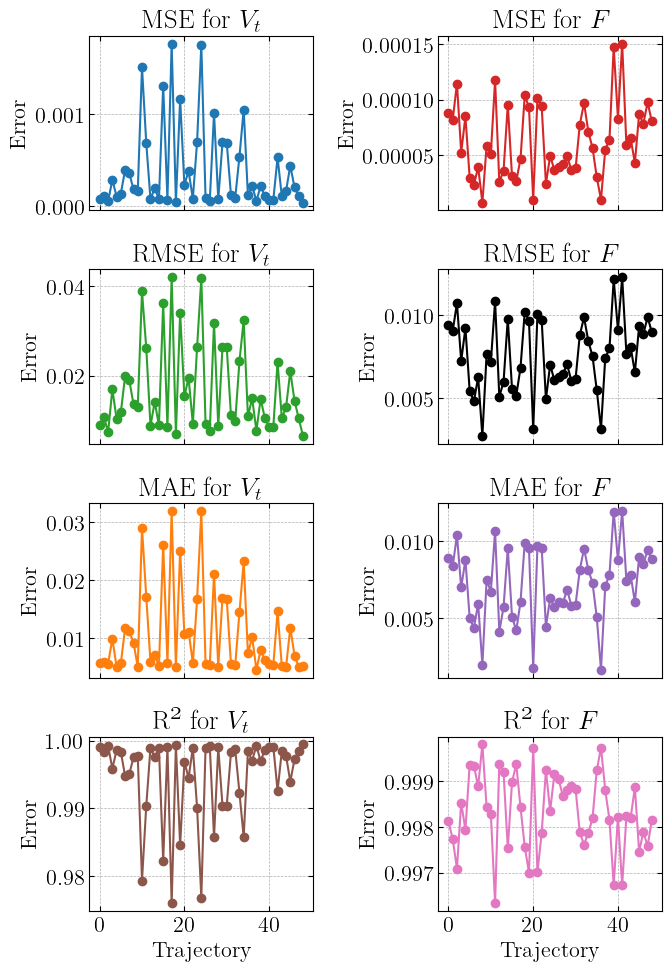

In [51]:
def metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)
    return mse, rmse, mae, r2


def evaluate_metrics(model, x, y):
    model.eval()
    mse = np.zeros((torch.unique(x[:, -1]).numel(),2))
    rmse = np.zeros_like(mse)
    mae = np.zeros_like(mse)
    r2 = np.zeros_like(mse)
    j = 0
    for traj in x[:,-1].unique():
        x_traj = x[x[:,-1] == traj][:,:-1]
        y_traj = y[y[:,-1] == traj][:,:-1]
        y_pred_np, _, _, _ = evaluate(model, x_traj, y_traj);

        y_true = y_traj.numpy()

        mse[j,0], rmse[j,0], mae[j,0], r2[j,0] = metrics(y_true[:,0], y_pred_np[:,0])
        mse[j,1], rmse[j,1], mae[j,1], r2[j,1] = metrics(y_true[:,1], y_pred_np[:,1])
        print(f"Test MSE: [{mse[j,0]:.3e},{mse[j,1]:.3e}], RMSE: [{rmse[j,0]:.3e},{rmse[j,1]:.3e}], MAE: [{mae[j,0]:.3e},{mae[j,1]:.3e}], R2: [{r2[j,0]:.3f},{r2[j,1]:.3f}]")
        j += 1
    return mse, rmse, mae, r2

mse, rmse, mae, r2 = evaluate_metrics(model, x_test, y_test);

f, ax = plt.subplots(4, 2, figsize=(7, 10),sharex=True)

ax[0,0].plot(mse[:,0], 'o-', color = colors[0])
ax[0,1].plot(mse[:,1], 'o-', color = colors[1])
ax[1,0].plot(rmse[:,0], 'o-', color = colors[2])
ax[1,1].plot(rmse[:,1], 'o-', color = colors[3])
ax[2,0].plot(mae[:,0], 'o-', color = colors[4])
ax[2,1].plot(mae[:,1], 'o-', color = colors[5])
ax[3,0].plot(r2[:,0], 'o-', color = colors[6])
ax[3,1].plot(r2[:,1], 'o-', color = colors[7])

ax[0,0].set_title('MSE for $V_t$')
ax[0,1].set_title('MSE for $F$')    
ax[1,0].set_title('RMSE for $V_t$')
ax[1,1].set_title('RMSE for $F$')
ax[2,0].set_title('MAE for $V_t$')
ax[2,1].set_title('MAE for $F$')
ax[3,0].set_title('R² for $V_t$')
ax[3,1].set_title('R² for $F$')
ax[3,0].set_xlabel('Trajectory')
ax[3,1].set_xlabel('Trajectory')
for a in ax.flat:
    a.set_ylabel('Error')
    a.grid(True, ls='--', lw=0.5)
plt.tight_layout()
plt.show()


In [86]:
save_model = True
if save_model:
    model_name = 'JH_model'
    # check if the file already exists and if so, append a number to the name
    model_number = 8
    save_path = Path(f'multi_models/JH_model_{model_number}_N{N_trajs}.pth')
    if save_path.exists():
        while save_path.exists():
            save_path = Path(f'multi_models/{model_name}_{model_number}_N{N_trajs}.pth')
            model_number += 1
        torch.save(model.state_dict(), f'multi_models/{model_name}_{model_number}_N{N_trajs}.pth')
    else:
        torch.save(model.state_dict(), f'multi_models/{model_name}_{model_number}_N{N_trajs}.pth')
    multi_exp_log.exp_log(model, history, name=f'{model_name}_{model_number}_N{N_trajs}', N_trajs = N_trajs, mse = mse, mae = mae)

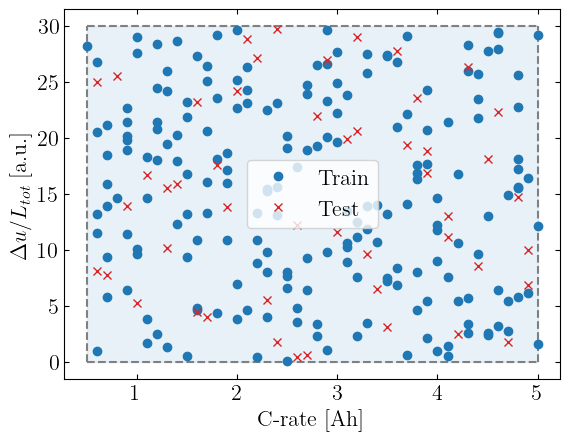

In [114]:
u_C_pairs_test = data.loc[(data['t'] == 0) & (data['trajectory'] > int(0.8 * N_trajs)), ['u_par', 'C']]
u_C_pairs_train = data.loc[(data['t'] == 0) & (data['trajectory'] <= int(0.8 * N_trajs)), ['u_par', 'C']]
plt.xlabel('C-rate [Ah]')
plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
plt.vlines(0.5,0,30, color='gray', linestyle='--')
plt.vlines(5,0,30, color='gray', linestyle='--')
plt.hlines(0,0.5,5, color='gray', linestyle='--')
plt.hlines(30,0.5,5, color='gray', linestyle='--')
plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
plt.plot(u_C_pairs_train['C'], u_C_pairs_train['u_par'], 'o', label = 'Train', color = colors[0])
plt.plot(u_C_pairs_test['C'], u_C_pairs_test['u_par'], 'x', label = 'Test', color = colors[1])
plt.legend()

In [115]:
mse_train, rmse_train, mae_train, r2_train = evaluate_metrics(model, x_train, y_train);

Test MSE: [1.039e-04,1.011e-05], RMSE: [1.020e-02,3.179e-03], MAE: [6.866e-03,2.026e-03], R2: [0.999,1.000]
Test MSE: [5.364e-04,8.595e-05], RMSE: [2.316e-02,9.271e-03], MAE: [1.417e-02,8.972e-03], R2: [0.992,0.997]
Test MSE: [6.199e-05,1.465e-04], RMSE: [7.873e-03,1.210e-02], MAE: [4.896e-03,1.150e-02], R2: [0.999,0.997]
Test MSE: [8.381e-05,1.375e-04], RMSE: [9.155e-03,1.173e-02], MAE: [5.387e-03,1.135e-02], R2: [0.999,0.997]
Test MSE: [4.341e-04,1.027e-04], RMSE: [2.084e-02,1.013e-02], MAE: [1.241e-02,9.831e-03], R2: [0.994,0.997]
Test MSE: [1.573e-04,3.021e-05], RMSE: [1.254e-02,5.497e-03], MAE: [6.394e-03,5.274e-03], R2: [0.998,0.999]
Test MSE: [1.047e-03,2.767e-05], RMSE: [3.236e-02,5.260e-03], MAE: [2.202e-02,4.828e-03], R2: [0.985,0.999]
Test MSE: [9.842e-05,2.177e-05], RMSE: [9.921e-03,4.665e-03], MAE: [6.133e-03,3.924e-03], R2: [0.999,0.999]
Test MSE: [4.887e-05,4.701e-05], RMSE: [6.991e-03,6.856e-03], MAE: [4.452e-03,6.214e-03], R2: [0.999,0.999]
Test MSE: [1.785e-04,8.684e-

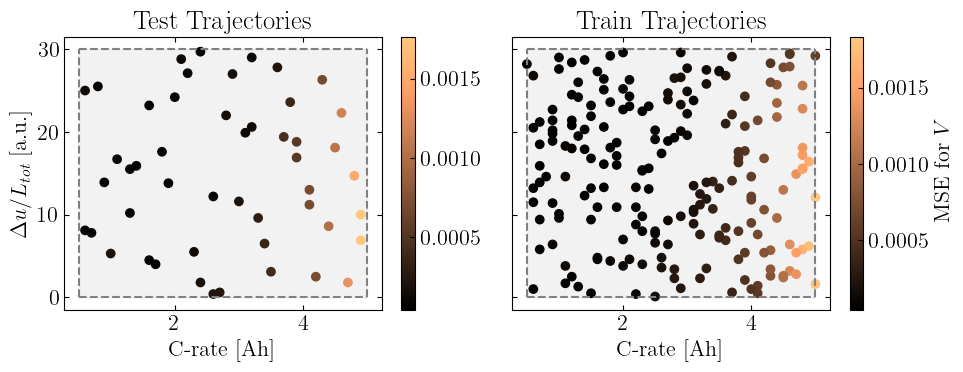

In [116]:
f, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for a in ax.flat:
    a.vlines(0.5,0,30, color='gray', linestyle='--')
    a.vlines(5,0,30, color='gray', linestyle='--')
    a.hlines(0,0.5,5, color='gray', linestyle='--')
    a.hlines(30,0.5,5, color='gray', linestyle='--')
    a.set_xlabel('C-rate [Ah]')
    a.fill_between([0.5, 5], 0, 30, color='gray', alpha=0.1)

ax[0].set_ylabel(r'$\Delta u / L_{tot}$ [a.u.]')

# Scatter plots with different colormaps
sc0 = ax[0].scatter(
    u_C_pairs_test['C'],
    u_C_pairs_test['u_par'],
    c=mse[:,0],
    cmap='copper',   # changed color
    label='Test'
)

sc1 = ax[1].scatter(
    u_C_pairs_train['C'],
    u_C_pairs_train['u_par'],
    c=mse_train[:,0],
    cmap='copper',   # different color
    label='Train'
)

# Attach each colorbar to its own axis
cb0 = plt.colorbar(sc0, ax=ax[0])
cb1 = plt.colorbar(sc1, ax=ax[1], label='MSE for $V$')

ax[0].set_title('Test Trajectories')
ax[1].set_title('Train Trajectories')
plt.tight_layout()


Text(0, 0.5, 'MSE')

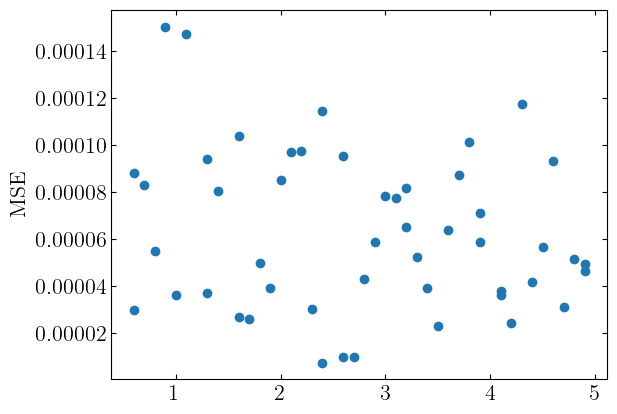

In [117]:
# mean mse for each C

plt.scatter(u_C_pairs_test['C'],mse[:,1],color=colors[0],label='Test')
# find traj_length for each trajectory
# traj_lengths = data.groupby('trajectory').size()
# traj_lengths_train = traj_lengths[traj_lengths.index <= int(0.8 * N_trajs)]
# traj_lengths_test = traj_lengths[traj_lengths.index > int(0.8 * N_trajs)]
# plt.scatter(traj_lengths_train.values,mse_train[:,1], color=colors[0], label='Train')
# plt.xlabel('Trajectory length')
plt.ylabel('MSE')

Text(0.5, 0, 'C-rate [Ah]')

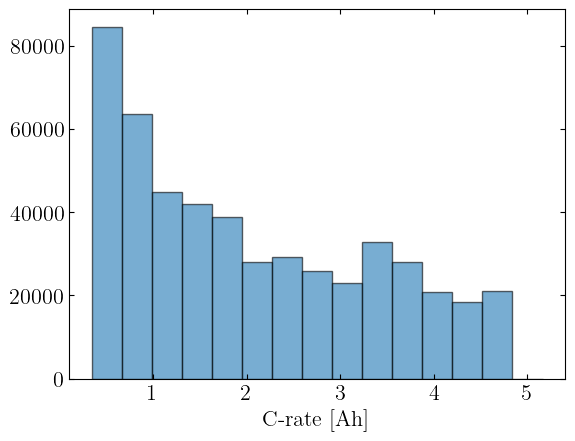

In [6]:
# find binned average number of point for each C bin
bins = np.linspace(0.5,5,15)
bin_count = np.zeros_like(bins)
for i,b in enumerate(bins):
    bin_count[i] = ((data['C'] > b) & (data['C'] <= b + (bins[1]-bins[0]))).sum()

plt.bar(bins, bin_count, width=(bins[1]-bins[0]), alpha=0.6, facecolor=colors[0], label='Count in bin', edgecolor='black')
plt.xlabel('C-rate [Ah]')

In [119]:
# def diff_U1(U1):
#     # check if U1 is torch tensor, if so convert to numpy
#     if isinstance(U1, torch.Tensor):
#         U1 = U1.detach().numpy()
#     dU1 = np.zeros(len(U1))
#     dU1[:-1] = np.diff(U1)
#     dU1[-1] = dU1[-2]  # Pad the end with the last value to maintain the same length

#     return dU1


# dU1 = diff_U1(U1)

# plt.plot(data['soc'][data['trajectory'] == traj_eval].values, dU1, label=r'Predicted $U_1$', color = colors[2])